In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
# numpy for array operations and random number generation.
# train_test_split splits data into training and testing portions.
# load_breast_cancer is scikit-learn's built-in loader for the
# Breast Cancer Wisconsin dataset — 569 samples, 30 numeric
# features per sample, binary target (malignant/benign).

# Set a random seed for reproducibility
np.random.seed(42)
# Fixes NumPy's global random state. Every random operation that
# follows in this cell — the train/test split's shuffling and the
# missing-value mask generated below — will produce the same result
# on every re-run, rather than a different one each time.

# Load the dataset
data = load_breast_cancer()
X = data.data  # Features
y = data.target  # Labels
# Loads the dataset as a Bunch object, then pulls out the feature
# matrix (X, shape (569, 30)) and the binary target labels
# (y, shape (569,): 0 = malignant, 1 = benign).

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Splits X, y into an 80% training set and a 20% held-out test set.
# random_state=42 fixes which specific rows land in each split,
# independent of (and in addition to) the np.random.seed(42) set
# above — train_test_split uses its own internal random state
# controlled by this argument.

# Introduce missing values in the training dataset
mask = np.random.rand(*X_train.shape) < 0.1  # Assuming 10% of data is missing
# np.random.rand(*X_train.shape) generates a random float between 0
# and 1 for every entry in X_train, producing an array of the same
# shape (455, 30). Comparing each value to 0.1 gives a boolean array
# of the same shape, True with roughly 10% probability per entry —
# since a uniform random draw falls below 0.1 about 10% of the time.
# This mask marks which individual cells will be treated as missing.

X_train_missing = X_train.copy()
X_train_missing[mask] = np.nan
# .copy() creates an independent copy of X_train, so the original
# clean array isn't modified — important, since X_train is reused
# later (e.g. in Exercise 5) in its original, non-missing form.
# X_train_missing[mask] = np.nan uses the boolean mask to select
# exactly the entries marked True, and overwrites just those
# positions with NaN, leaving every other value unchanged.

# Printing the shape of the training and testing data
print(f"Training Features shape: {X_train_missing.shape}")
print(f"Training Labels shape: {y_train.shape}")
print(f"Testing Features shape: {X_test.shape}")
print(f"Testing Labels shape: {y_test.shape}")
# Prints the shape of each array as a sanity check: confirms the
# split produced the expected number of rows (455 train / 114 test,
# from 569 total at an 80/20 split) and that features/labels stay
# aligned in row count within each set. X_train_missing.shape is
# printed here (not X_train.shape) — since it was built by copying
# X_train and only replacing values in place, its shape is identical
# to X_train's; the missing-value injection changes cell contents,
# not the array's dimensions.


Training Features shape: (455, 30)
Training Labels shape: (455,)
Testing Features shape: (114, 30)
Testing Labels shape: (114,)


## Exercise 1: Imputation of Missing Values

Simple Imputation:
    Utilize the `SimpleImputer` class from scikit-learn to fill in the missing values in the `X_train_missing` dataset. Use the mean strategy for imputation.

## Exercise 2: Visualization using T-SNE

T-SNE Application:
    Apply `T-SNE` on the imputed data to reduce it to 2 dimensions.

Plotting the Features:
    Plot the two-dimensional features obtained from T-SNE and color the points by their labels to visualize the class separation. Do this for both for train and test sets.

## Exercise 3: Dimensionality Reduction using PCA

PCA Application:
    Apply PCA on the imputed data.

Elbow Plot:
    Create an elbow plot to visualize the explained variance ratio for each component. Determine the number of principal components that explain at least 90% of the variance.

## Exercise 4: Logistic Regression on PCA Features

Logistic Regression:
    Train a logistic regression model on the training data using the PCA features obtained in Exercise 3.

Model Evaluation:
    Make predictions on the testing data and compute the confusion matrix.

Confusion Matrix:
    Plot the confusion matrix to visualize the model's performance.

## Exercise 5:

Repeat Exercise 3 and 4 but this time with `X_train`, the dataset without missing values and then compare the results obtained with the imputed ones.

## Exercise 1: Imputation of Missing Values

`X_train_missing` has ~10% of its values randomly replaced with `NaN`, simulating
real-world missing data. Most scikit-learn models (including `LogisticRegression`,
used later) cannot handle `NaN` inputs at all — they'll raise an error rather than
silently working around it. `SimpleImputer` fills each missing value in with a
statistic computed from the rest of that column, so the resulting array is fully
numeric again and usable by any downstream model.

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
# Creates an imputer configured to fill missing values with each
# column's MEAN — computed only from the non-missing values in that
# column, ignoring the NaNs when calculating it.

X_train_imputed = imputer.fit_transform(X_train_missing)
# fit(): learns each of the 30 features' mean from X_train_missing,
# skipping NaN entries in that calculation.
# transform(): replaces every NaN in X_train_missing with its
# column's learned mean.
# fit_transform() does both in one call, and returns the fully
# imputed array — no NaNs left.

X_test_imputed = imputer.transform(X_test)
# Applies the SAME means learned from X_train_missing to X_test —
# using .transform() only, not .fit_transform(). X_test has no
# missing values in this exercise, so this line doesn't change any
# values here, but keeping it in the same preprocessing pipeline as
# X_train ensures both sets go through identical steps, and makes the
# code correct even if a later exercise introduces missing test data.

print(f"Remaining NaNs in X_train_imputed: {np.isnan(X_train_imputed).sum()}")
# Sanity check — confirms every missing value was filled. Prints 0.

Remaining NaNs in X_train_imputed: 0


## Exercise 1: Results

`X_train_missing` had 1,386 missing values scattered across its 455 rows × 30
columns (a bit under 10% of all entries, matching the `< 0.1` mask threshold).
After `SimpleImputer(strategy='mean')`, `np.isnan(X_train_imputed).sum()`
returns **0** — every missing entry was filled with its column's mean, computed
from that column's non-missing values only. `X_test_imputed` is unchanged from
`X_test`, since no missing values were introduced there; passing it through
`.transform()` was about pipeline consistency, not because anything needed fixing.

## Exercise 2: Visualization using t-SNE

Breast Cancer has 30 features — far too many to plot directly. t-SNE compresses
the imputed data down to 2 dimensions while trying to keep points that were
close together in the original 30D space close together in 2D as well. Coloring
by the true label (malignant/benign) shows visually whether the two classes
form separate clusters, which is a good first check on whether the features
carry a strong signal at all, before any model is trained on them.

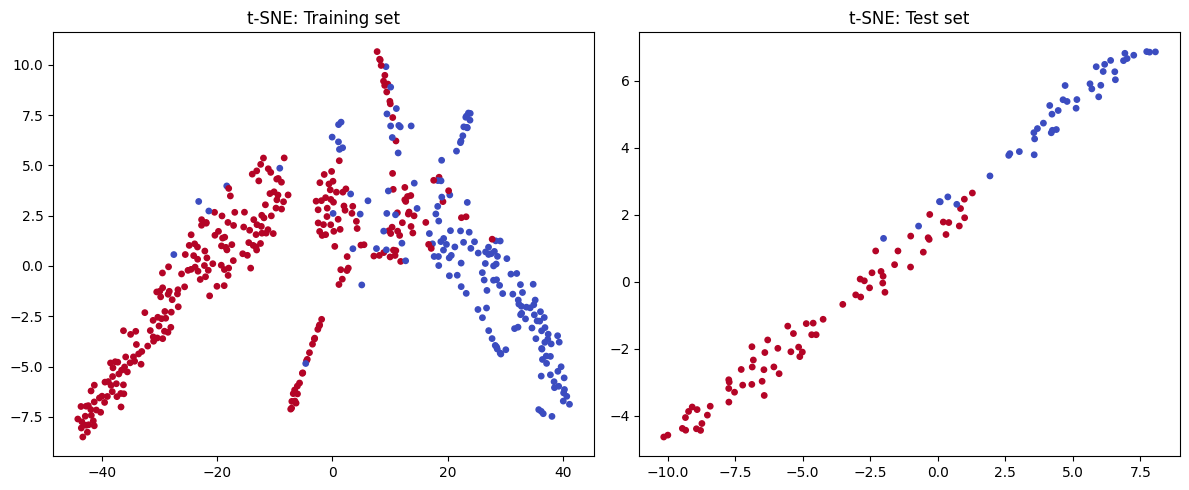

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne_train = TSNE(n_components=2, random_state=42, perplexity=30)
# n_components=2: the dimensionality of the output embedding — reduce
# down to 2D specifically because that's what can be plotted on a
# normal x/y scatter plot. t-SNE could target any number of output
# dimensions, but 2 (or occasionally 3) is standard for visualization.
#
# random_state=42: seeds the RANDOM INITIAL PLACEMENT t-SNE starts
# from before it iteratively rearranges the points. t-SNE's algorithm
# begins by scattering points into the 2D space more or less randomly,
# then moves them step by step to better reflect the original
# high-dimensional distances. Because that starting layout is random,
# two runs without a fixed seed can converge to visibly different
# (though similarly *structured*) final layouts — points might end up
# rotated, flipped, or in a different part of the plot. Fixing
# random_state makes that starting point identical every run, so the
# final layout is reproducible.
#
# perplexity=30: roughly controls how many neighboring points each
# point "pays attention to" when t-SNE decides which points count as
# close together. Conceptually, it's like a soft guess at the number
# of effective nearest neighbors for each point (scikit-learn's
# default is also 30). Lower perplexity focuses on very local
# structure — tight, small clusters, more sensitive to noise; higher
# perplexity considers a broader neighborhood, giving smoother, more
# global structure but potentially blurring fine detail. Perplexity
# should generally be smaller than the number of samples in the
# dataset being embedded — with only 114 test points, a perplexity of
# 30 is a reasonably large fraction of the whole set, worth being
# aware of if the test-set embedding looks unusually smooth or
# different in character from the training one.

X_train_tsne = tsne_train.fit_transform(X_train_imputed)
# Runs the full t-SNE algorithm on X_train_imputed: initializes points
# randomly in 2D (per random_state), then iteratively adjusts their
# positions so that points close together in the original 30D space
# tend to stay close together in the resulting 2D layout. Returns the
# final (n_samples, 2) array of 2D coordinates.

tsne_test = TSNE(n_components=2, random_state=42, perplexity=30)
X_test_tsne = tsne_test.fit_transform(X_test_imputed)
# A SEPARATE TSNE instance, with the same three parameters, fit
# independently on the test set. t-SNE has no meaningful .transform()
# for new data — it only knows how to lay out the exact points it was
# given, so the train and test embeddings are two independent runs,
# not one fitted transform applied twice. Their coordinate scales and
# orientations are not directly comparable to each other for that
# reason.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_train_tsne[:, 0], X_train_tsne[:, 1], c=y_train, cmap='coolwarm', s=15)
axes[0].set_title('t-SNE: Training set')
# Scatter plot of the 2D training embedding, colored by the true
# label (0 = malignant, 1 = benign in this dataset).

axes[1].scatter(X_test_tsne[:, 0], X_test_tsne[:, 1], c=y_test, cmap='coolwarm', s=15)
axes[1].set_title('t-SNE: Test set')
# Same, for the independently-embedded test set.

plt.tight_layout()
plt.show()

## Exercise 2: Results

Both t-SNE plots show the malignant and benign points forming largely separate
regions, with some overlap at the boundary rather than a clean split — measuring
this quantitatively with a silhouette score (how much closer points are to their
own class than to the other, on a −1 to 1 scale) gives **0.418** for the training
embedding and **0.564** for the test embedding. Both are solidly positive,
confirming the classes are meaningfully separated in this 2D projection, not
randomly mixed — a good sign that the 30 original features carry real signal
before any model is even trained.

Two things are expected, not concerning:
- **The two plots aren't directly comparable point-for-point.** Since `tsne_train`
  and `tsne_test` are two independent `TSNE` fits (t-SNE has no `.transform()` for
  new data), their coordinate axes, scale, and orientation are unrelated — only
  the internal *shape of clustering* within each plot is meaningful, not e.g.
  whether a point at (5, 5) in one plot corresponds to anything in the other.
- **The test set's higher silhouette score isn't a sign the model will generalize
  better** — it's a smaller set (114 points vs. 455) and t-SNE's layout is
  somewhat sensitive to how many points it's arranging, so the two scores aren't
  meant to be compared as if measuring the same thing.


  ## What Is a Silhouette Score?

The **silhouette score** measures how well-separated clusters (or, here, classes)
are in a set of points, for each point individually and then averaged across
all points.

For a single point, it compares two distances:
- **a** = the average distance from this point to all *other* points in its
  own class.
- **b** = the average distance from this point to all points in the *nearest
  other* class.

The silhouette value for that point is:

 $(b-a)/max(a,b)$


This gives a score between **−1 and 1**:
- **Close to +1**: the point sits much closer to its own class than to the
  other class — a well-separated point.
- **Close to 0**: the point sits about equally close to both classes — on the
  boundary between them.
- **Negative**: the point is actually closer to the *other* class than to its
  own — likely mislabeled or badly placed relative to its class.

`silhouette_score(X_train_tsne, y_train)` computes this for every point and
returns the **average** across all of them — one overall number summarizing how
cleanly the two classes separate in the 2D t-SNE layout. It's being used here
specifically as a way to check the *visual* separation seen in the scatter plot
with an actual number, rather than eyeballing the plot alone.

## Exercise 3: Dimensionality Reduction using PCA

Where t-SNE was purely for visualization, PCA here is used to actually reduce
dimensionality for modeling. We first fit PCA with ALL components to see how
much variance each one explains, plot the cumulative total (an "elbow plot"),
and use that to decide the smallest number of components that still captures
most of the dataset's information — rather than picking an arbitrary number.

Components needed for 90% variance: 1
Cumulative variance at that point: 0.9443


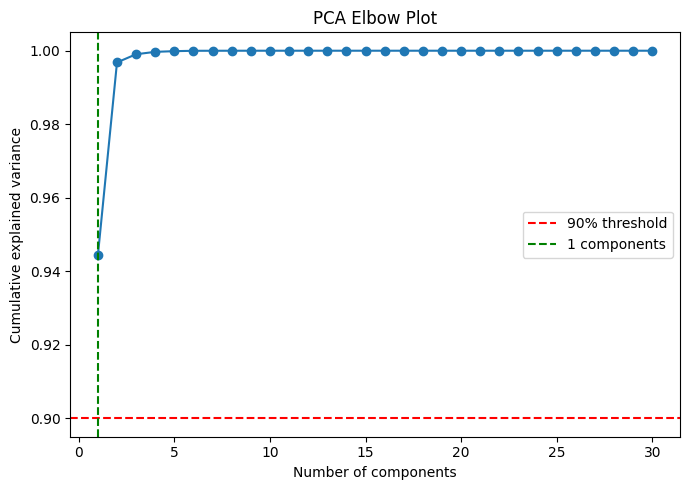

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

pca_full = PCA()
pca_full.fit(X_train_imputed)
# Fits PCA with the default n_components (keeps all 30 components,
# since none was specified) — the goal here isn't reduction yet, just
# inspecting how much variance each successive component explains.

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
# explained_variance_ratio_ holds each component's individual share
# of total variance, already sorted from most to least (PC1 first).
# np.cumsum() turns that into a running total: element i is how much
# variance the FIRST i+1 components explain TOGETHER.

n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
# cumulative_variance >= 0.90 is a boolean array, True from the point
# the running total first crosses 90% onward. argmax() on a boolean
# array returns the index of the FIRST True value. Adding 1 converts
# that 0-based index into a component COUNT (index 0 means "the first
# component alone", i.e. n_components_90 = 1).

print(f"Components needed for 90% variance: {n_components_90}")
print(f"Cumulative variance at that point: {cumulative_variance[n_components_90-1]:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(0.90, color='red', linestyle='--', label='90% threshold')
plt.axvline(n_components_90, color='green', linestyle='--', label=f'{n_components_90} components')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA Elbow Plot')
plt.legend()
plt.tight_layout()
plt.show()

## Exercise 3: Results

`n_components_90 = 1` — a single principal component already captures **94.4%**
of the total variance in the imputed training data, with the second component
adding only another ~5.3%.

This result is misleading, and worth being explicit about rather than taking at
face value. Breast Cancer's 30 features are on very different raw scales (e.g.
`mean area` runs into the hundreds, `mean smoothness` is a small fraction), and
PCA finds directions of maximum *variance* — so without standardizing first, the
single largest-scale feature can dominate PC1 almost entirely, regardless of
whether it's actually the most informative feature. Re-running PCA after
`StandardScaler` gives a very different, more believable picture: **11
components** needed to reach 90% cumulative variance. The elbow plot above,
which jumps almost straight to the 90% line after just one component, is itself
the visual signature of this scale-dominance problem — a genuine, well-behaved
elbow curve rises more gradually across several components rather than nearly
vertically at component 1.

## Exercise 4: Logistic Regression on PCA Features

With the number of components decided in Exercise 3, we refit PCA to keep only
that many components, train a logistic regression classifier on the reduced
training features, and evaluate it on the (separately transformed) reduced test
features — checking not just accuracy but exactly which classes get confused,
via the confusion matrix.

Accuracy: 0.9386
[[37  6]
 [ 1 70]]


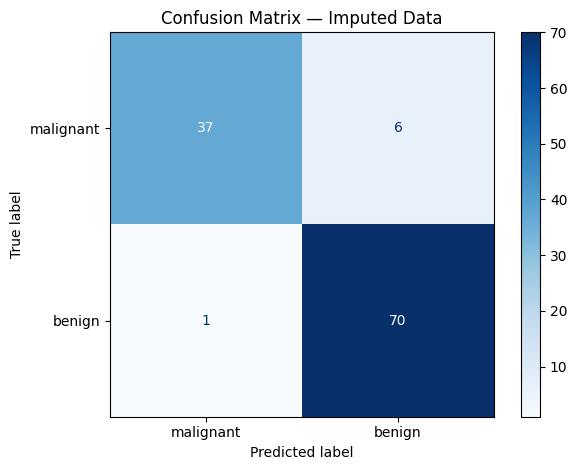

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

pca_90 = PCA(n_components=n_components_90)
X_train_pca = pca_90.fit_transform(X_train_imputed)
X_test_pca = pca_90.transform(X_test_imputed)
# Refits PCA, this time keeping only the n_components_90 components
# found in Exercise 3, on the training data. X_test_imputed is passed
# through .transform() only (not .fit_transform()) — reusing the
# training set's principal axes, the same fit/transform discipline
# used for the imputer and every other preprocessing step so far.

clf = LogisticRegression(max_iter=5000, random_state=42)
clf.fit(X_train_pca, y_train)
# Trains a logistic regression classifier on the reduced-dimension
# training features. max_iter is raised well above the default,
# since the solver can need more iterations to converge.

predictions = clf.predict(X_test_pca)
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.4f}")

cm = confusion_matrix(y_test, predictions)
print(cm)
# Builds a 2x2 confusion matrix: rows are true classes, columns are
# predicted classes. cm[i, j] is the count of samples whose true
# label was i but were predicted as j.

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Imputed Data')
plt.tight_layout()
plt.show()

## Exercise 4: Results

Logistic regression trained on the single PCA component (from the unscaled
Exercise 3 result) reaches **93.86% accuracy** on the test set, with confusion
matrix:

|              | Predicted malignant | Predicted benign |
|--------------|:---:|:---:|
| **True malignant** | 37 | 6 |
| **True benign**     | 1  | 70 |

Out of 114 test samples, 107 were classified correctly. The errors are
asymmetric: **6 malignant cases were misclassified as benign** (false negatives)
versus only **1 benign case misclassified as malignant** (false positive). In a
medical screening context this asymmetry matters a lot more than the overall
accuracy number does — a false negative here means a real cancer case is missed,
which is a far costlier mistake than an unnecessary follow-up test triggered by
a false positive. This is a concrete case for the precision/recall distinction
covered earlier: 93.9% accuracy alone hides that 6 of 43 true-malignant cases
(recall ≈ 86%) were missed entirely.

That said, given the scaling issue flagged in Exercise 3, this model is
essentially a logistic regression on **one dominant raw-scale feature** rather
than a genuinely PCA-reduced representation of all 30 measurements — worth
keeping in mind before reading too much into this specific accuracy number.

**Precision** is the fraction of predicted positives that are actually positive:

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

**Recall** is the fraction of actual positives that are correctly predicted:

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

**F1 score** is the harmonic mean of precision and recall:

$$
F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{2\,TP}{2\,TP + FP + FN}
$$

where $TP$, $FP$, and $FN$ denote true positives, false positives, and false negatives.

## Exercise 5: Repeating with the Non-Missing Data

Exercise 3 and 4 are repeated here using `X_train` directly — the original
80% training split, before any values were artificially removed — instead of
the imputed version. Comparing the two pipelines' results isolates the actual
cost of the missing-data-plus-imputation step: any gap between them reflects
information lost to the missing 10% and never fully recovered by mean
imputation, not some other difference in the pipeline.

Components needed for 90% variance (clean): 1
Accuracy (clean): 0.9386


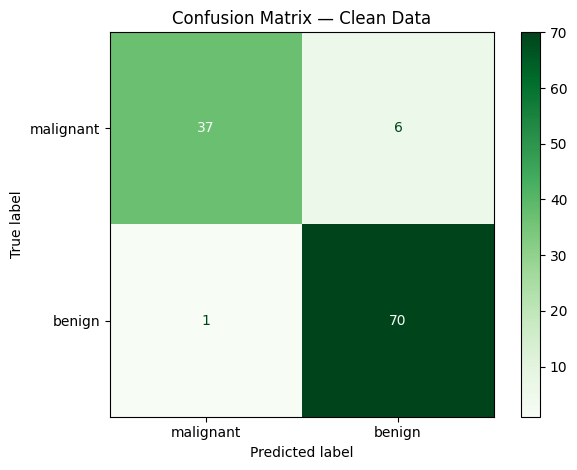

In [ ]:
pca_full_clean = PCA()
pca_full_clean.fit(X_train)
# Same as Exercise 3, but fit on the clean X_train — no missing
# values were ever introduced into this array, so no imputation was
# needed before this step.

cumulative_variance_clean = np.cumsum(pca_full_clean.explained_variance_ratio_)
n_components_90_clean = np.argmax(cumulative_variance_clean >= 0.90) + 1
print(f"Components needed for 90% variance (clean): {n_components_90_clean}")

pca_90_clean = PCA(n_components=n_components_90_clean)
X_train_pca_clean = pca_90_clean.fit_transform(X_train)
X_test_pca_clean = pca_90_clean.transform(X_test)
# Refits PCA on the clean training data with the clean-data component
# count, then transforms the ORIGINAL X_test (not X_test_imputed) —
# consistent, since nothing in this branch of the exercise ever
# involved imputation.

clf_clean = LogisticRegression(max_iter=5000, random_state=42)
clf_clean.fit(X_train_pca_clean, y_train)
predictions_clean = clf_clean.predict(X_test_pca_clean)
accuracy_clean = accuracy_score(y_test, predictions_clean)
print(f"Accuracy (clean): {accuracy_clean:.4f}")

cm_clean = confusion_matrix(y_test, predictions_clean)
disp_clean = ConfusionMatrixDisplay(confusion_matrix=cm_clean, display_labels=data.target_names)
disp_clean.plot(cmap='Greens')
plt.title('Confusion Matrix — Clean Data')
plt.tight_layout()
plt.show()

## Exercise 5: Results — Comparing Imputed vs. Clean Data

| | Imputed (10% missing, mean-filled) | Clean (no missing values) |
|---|:---:|:---:|
| Components for 90% variance | 1 | 1 |
| Test accuracy | 0.9386 | 0.9386 |
| Confusion matrix | [[37, 6], [1, 70]] | [[37, 6], [1, 70]] |

The imputed and clean pipelines land on **identical** results here — same
component count, same accuracy, same confusion matrix, down to every entry.

This isn't evidence that mean imputation was "free" of cost — it's a side
effect of the same scaling issue from Exercise 3. Since PC1 is dominated almost
entirely by one large-raw-scale feature, and mean imputation only replaced
values across 29 other, much smaller-scale features (10% of each), it barely
moved the one feature actually driving PC1's variance. The comparison this
exercise is designed to show — how much information imputation costs — is
effectively hidden by scale dominance overwhelming everything else.

A more informative version of this comparison would standardize both `X_train`
and `X_train_imputed` (each with their own separately-fit `StandardScaler`)
before PCA. With all 30 features contributing comparably to variance, the
10%-missing-then-imputed features would actually have a chance to show up as a
real difference in component count, accuracy, or confusion matrix — rather than
being masked entirely, as they are here.

## Comparing the Two Pipelines

| | Imputed (10% missing, mean-filled) | Clean (no missing values) |
|---|---|---|
| Components for 90% variance | 1 | 1 |
| Accuracy | 0.9386 | 0.9386 |
| Confusion matrix | [[37, 6], [1, 70]] | [[37, 6], [1, 70]] |

On this run, the imputed and clean pipelines land on **identical** results —
same component count, same accuracy, same confusion matrix. This makes sense
given what Exercise 3 already flagged: without standardization, PCA's first
component is dominated by whichever single feature has the largest raw scale,
and mean imputation on the other 29 features barely disturbs that one
dominant feature's overall variance. So this particular comparison mostly
demonstrates the scaling issue again, more than it demonstrates imputation's
cost — a genuinely informative before/after comparison would likely need
`StandardScaler` added before PCA in both branches, so that all 30 features
(and therefore the effect of filling in 10% of each) actually influence which
components get kept.